In [1]:
from pathlib import Path
import re
import pandas as pd
from IPython.display import display

RESULT_DIR = Path('/home/syx/workspace/HyperBat/results/diffusion_results')

FILE_PATTERN = re.compile(
    r'^(?P<kind>end2end|test)_'
    r'local(?P<local_num_cycles>\d+)_'
    r'global(?P<global_num_cycles>\d+)_'
    r'steps(?P<diffusion_steps>\d+)_'
    r'dim(?P<denoiser_hidden_dim>\d+)_'
    r'wsize(?P<window_size>\d+)_'
    r'stride(?P<stride>\d+)\.csv$'
)


def _resolve_result_dir(result_dir=RESULT_DIR):
    result_dir = Path(result_dir)
    if result_dir.exists():
        return result_dir
    alt_dir = Path.cwd() / 'results' / 'diffusion_results'
    if alt_dir.exists():
        return alt_dir
    raise FileNotFoundError(f'Cannot find diffusion results directory: {result_dir}')


def _parse_filename(path):
    match = FILE_PATTERN.match(path.name)
    if not match:
        return None
    info = match.groupdict()
    info['path'] = path
    for key in ['local_num_cycles', 'global_num_cycles', 'diffusion_steps', 'denoiser_hidden_dim', 'window_size', 'stride']:
        info[key] = int(info[key])
    return info


def show_csv_results(
    result_dir=RESULT_DIR,
    filters=None,
    sort_by=None,
):
    """显示每个CSV文件中每个dataset的平均指标

    核心逻辑：
    1. 根据 filters 选择 CSV 文件（只有完全匹配的才参与统计）
    2. 对每个 CSV 文件，按 dataset 分组，计算该 dataset 内的平均指标
    3. 每行 = 一个 CSV 文件的一个 dataset 的数据
    4. 对参数列检查：如果全部相同，则隐藏该列
    5. 每个 dataset 单独一个表，按 mape 标记最优和次优行

    Parameters
    ----------
    result_dir : str or Path
        Folder containing result csv files.
    filters : dict or None
        Filename parameter filters, e.g. {'diffusion_steps': 1}.
        只有匹配所有 filter 条件的 CSV 文件才会被选中。
        未指定的参数可以有多个值。
    sort_by : list or None
        Sort keys for the final table. 默认按所有参数 + dataset 排序。
    """
    result_dir = _resolve_result_dir(result_dir)
    filters = filters or {}

    csv_files = []
    meta_rows = []
    for path in sorted(result_dir.glob('*.csv')):
        meta = _parse_filename(path)
        if meta is None or meta['kind'] != 'end2end':
            continue
        if any(meta.get(k) != v for k, v in filters.items()):
            continue
        csv_files.append(path)
        meta_rows.append({k: v for k, v in meta.items() if k != 'path'})

    if not csv_files:
        raise FileNotFoundError(f'No matching end2end csv files found in {result_dir} with filters={filters}')

    # 对每个 CSV 文件单独处理，每行 = 一个 CSV 的一个 dataset
    metric_cols = ['mse', 'mae', 'rmse', 'mape']
    param_cols = ['local_num_cycles', 'global_num_cycles', 'diffusion_steps', 'denoiser_hidden_dim', 'window_size', 'stride']

    frames = []
    for path, meta in zip(csv_files, meta_rows):
        df = pd.read_csv(path)

        # 对该 CSV 按 dataset 分组求平均
        grouped = df.groupby('dataset', as_index=False)[metric_cols].mean()

        # 为该 CSV 的结果添加参数列
        for key, value in meta.items():
            grouped[key] = value

        frames.append(grouped)

    all_data = pd.concat(frames, ignore_index=True)

    # 排序
    if sort_by is None:
        sort_by = param_cols + ['dataset']

    summary = all_data.sort_values(sort_by, ascending=True).reset_index(drop=True)

    # 检查哪些列全部一样
    hidden_cols = []
    hidden_values = {}

    for col in param_cols:
        if summary[col].nunique() == 1:
            hidden_cols.append(col)
            hidden_values[col] = summary[col].iloc[0]

    # 显示隐藏信息
    if hidden_cols:
        print("\n已隐藏全部相同的列：")
        for col in hidden_cols:
            print(f"  {col} = {hidden_values[col]}")
        print()

    print("根据MAPE指标高亮，最优行为绿色，次优行为红色。")

    # 每个dataset单独一个表
    for dataset in summary['dataset'].unique():
        dataset_mask = summary['dataset'] == dataset
        dataset_data = summary[dataset_mask].copy().reset_index(drop=True)

        # 重新排列列
        display_cols = ['dataset']
        for col in param_cols:
            if col not in hidden_cols:
                display_cols.append(col)
        display_cols.extend(metric_cols)

        display_df = dataset_data[display_cols].copy()

        # 对数值列进行格式化
        for col in metric_cols:
            display_df[col] = display_df[col].apply(lambda x: f'{x:.6f}')

        # 基于 mape 排名整行高亮：最优正绿色，次优正红色，字体黑色
        best_two = dataset_data['mape'].nsmallest(min(2, len(dataset_data))).index.tolist()
        best_idx = best_two[0] if len(best_two) >= 1 else None
        second_idx = best_two[1] if len(best_two) >= 2 else None

        def style_row_by_mape(row):
            if best_idx is not None and row.name == best_idx:
                return ['background-color: #00FF00; color: #000000'] * len(row)
            if second_idx is not None and row.name == second_idx:
                return ['background-color: #FF0000; color: #000000'] * len(row)
            return [''] * len(row)

        styled = display_df.style.apply(style_row_by_mape, axis=1)

        # 输出该dataset的表格
        display(styled)

    return summary


In [2]:
# 显示每个CSV文件中每个dataset的平均指标
# 特性：每个dataset单独一个表，按 mape 排名高亮（最优绿色，次优红色）

# 不指定 filter：所有 CSV 参与统计（150 行 = 25个CSV × 6个dataset）
# diffusion_steps 列会显示（因为有多个不同值）
result = show_csv_results()

# # 指定 filter：只有匹配条件的 CSV 参与统计
# # diffusion_steps 列会被隐藏（因为值恒定为 1）
# result = show_csv_results(filters={'diffusion_steps': 1})

# # 可以指定多个 filter
# result = show_csv_results(filters={'diffusion_steps': 1, 'local_num_cycles': 5})



已隐藏全部相同的列：
  denoiser_hidden_dim = 512
  window_size = 200
  stride = 50

根据MAPE指标高亮，最优行为绿色，次优行为红色。


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_CALCE,5,20,1,0.003692,0.051115,0.053302,0.057863
1,test_CALCE,5,20,3,0.005845,0.064675,0.067050,0.074316
2,test_CALCE,5,20,5,0.006587,0.066090,0.068708,0.076740
3,test_CALCE,5,20,10,0.006471,0.064714,0.067329,0.076255
4,test_CALCE,5,20,15,0.006946,0.069711,0.072065,0.080215
5,test_CALCE,5,20,20,0.008238,0.072705,0.075339,0.085298
6,test_CALCE,5,20,30,0.008611,0.075485,0.077936,0.086970
7,test_CALCE,5,20,40,0.010008,0.080958,0.083566,0.095187
8,test_CALCE,5,20,50,0.008543,0.074740,0.077451,0.087508
9,test_CALCE,5,20,75,0.009524,0.079653,0.082573,0.093781


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_HNEI,5,20,1,0.002487,0.042857,0.047653,0.051194
1,test_HNEI,5,20,3,0.003599,0.048306,0.053147,0.057938
2,test_HNEI,5,20,5,0.003683,0.049621,0.054663,0.059572
3,test_HNEI,5,20,10,0.006617,0.062955,0.068260,0.076131
4,test_HNEI,5,20,15,0.005120,0.056520,0.061534,0.068076
5,test_HNEI,5,20,20,0.005987,0.061798,0.066845,0.074933
6,test_HNEI,5,20,30,0.005287,0.055176,0.060414,0.066744
7,test_HNEI,5,20,40,0.006959,0.064223,0.069491,0.078326
8,test_HNEI,5,20,50,0.005262,0.056068,0.061916,0.067682
9,test_HNEI,5,20,75,0.005681,0.059027,0.064962,0.071230


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_HUST,5,20,1,0.003336,0.051882,0.052752,0.056129
1,test_HUST,5,20,3,0.003485,0.051605,0.052467,0.056048
2,test_HUST,5,20,5,0.003821,0.052788,0.053660,0.057407
3,test_HUST,5,20,10,0.004384,0.055078,0.055908,0.060429
4,test_HUST,5,20,15,0.004682,0.058022,0.058848,0.063035
5,test_HUST,5,20,20,0.004913,0.058644,0.059456,0.064293
6,test_HUST,5,20,30,0.005970,0.064512,0.065318,0.070173
7,test_HUST,5,20,40,0.005380,0.060644,0.061452,0.066104
8,test_HUST,5,20,50,0.005703,0.062729,0.063509,0.068502
9,test_HUST,5,20,75,0.005708,0.062166,0.062978,0.067944


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_MATR,5,20,1,0.006251,0.075404,0.076982,0.077450
1,test_MATR,5,20,3,0.006813,0.073534,0.075633,0.075823
2,test_MATR,5,20,5,0.007395,0.074220,0.076185,0.076405
3,test_MATR,5,20,10,0.008528,0.079186,0.081364,0.081634
4,test_MATR,5,20,15,0.010392,0.085691,0.087687,0.088178
5,test_MATR,5,20,20,0.009761,0.084066,0.086216,0.086794
6,test_MATR,5,20,30,0.014113,0.102254,0.104112,0.105229
7,test_MATR,5,20,40,0.012765,0.094862,0.097121,0.097805
8,test_MATR,5,20,50,0.012747,0.096651,0.098735,0.099534
9,test_MATR,5,20,75,0.011266,0.089012,0.091280,0.091739


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_NAion,5,20,1,0.001699,0.034910,0.040376,0.036739
1,test_NAion,5,20,3,0.002213,0.035875,0.041974,0.038108
2,test_NAion,5,20,5,0.002515,0.037961,0.044671,0.040318
3,test_NAion,5,20,10,0.002215,0.035812,0.042750,0.038540
4,test_NAion,5,20,15,0.002326,0.036261,0.043535,0.039181
5,test_NAion,5,20,20,0.002889,0.039873,0.046725,0.042829
6,test_NAion,5,20,30,0.002827,0.040618,0.047729,0.043745
7,test_NAion,5,20,40,0.002515,0.036754,0.043355,0.039545
8,test_NAion,5,20,50,0.002456,0.037442,0.044248,0.040145
9,test_NAion,5,20,75,0.008829,0.063363,0.069128,0.066815


,dataset,local_num_cycles,global_num_cycles,diffusion_steps,mse,mae,rmse,mape
0,test_ZNion,5,20,1,0.005176,0.061258,0.064505,0.067803
1,test_ZNion,5,20,3,0.010286,0.082466,0.085657,0.091625
2,test_ZNion,5,20,5,0.022040,0.126410,0.129102,0.139751
3,test_ZNion,5,20,10,0.034375,0.164414,0.166687,0.182496
4,test_ZNion,5,20,15,0.033706,0.165248,0.167449,0.183149
5,test_ZNion,5,20,20,0.028471,0.146906,0.149412,0.163207
6,test_ZNion,5,20,30,0.025504,0.136583,0.139253,0.151342
7,test_ZNion,5,20,40,0.023281,0.128742,0.131482,0.143246
8,test_ZNion,5,20,50,0.019739,0.120631,0.123322,0.134837
9,test_ZNion,5,20,75,0.016670,0.107893,0.110864,0.121060


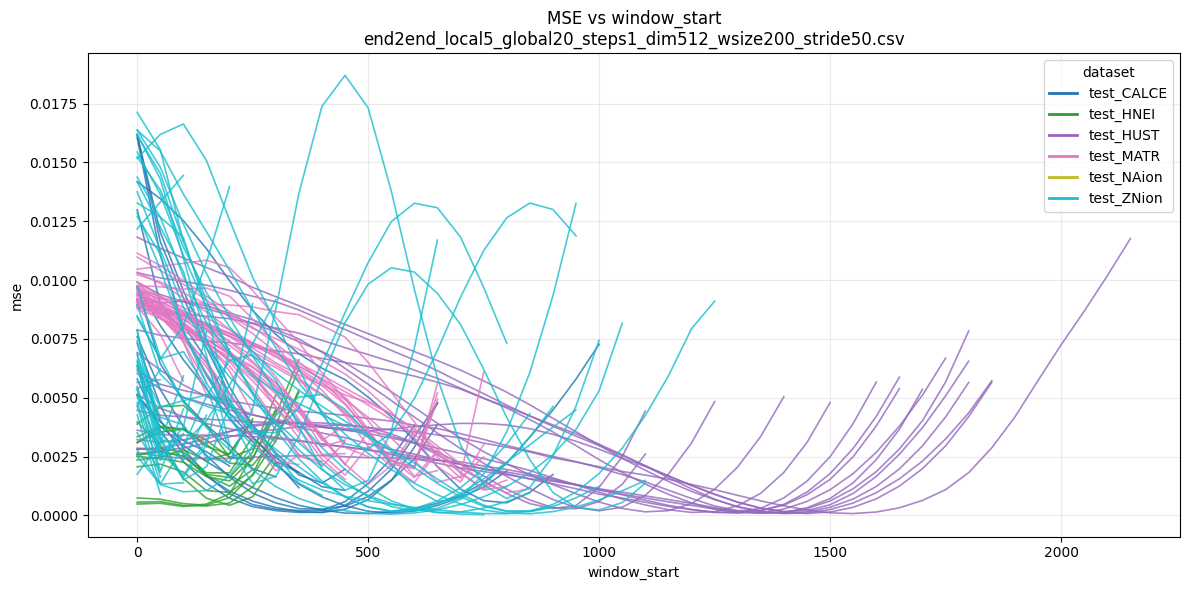

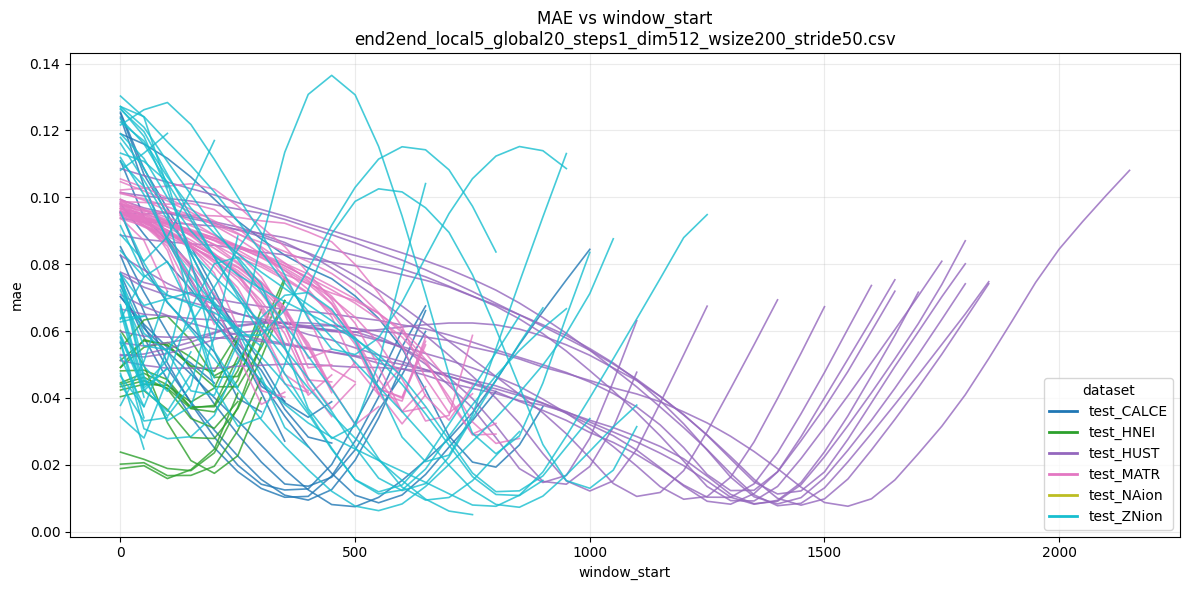

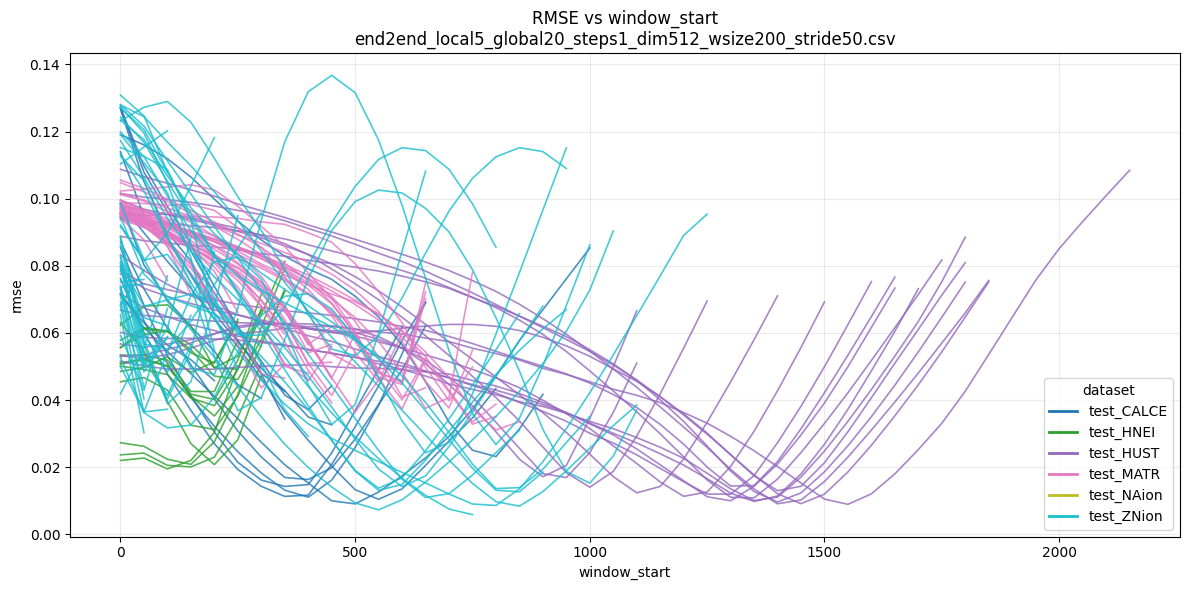

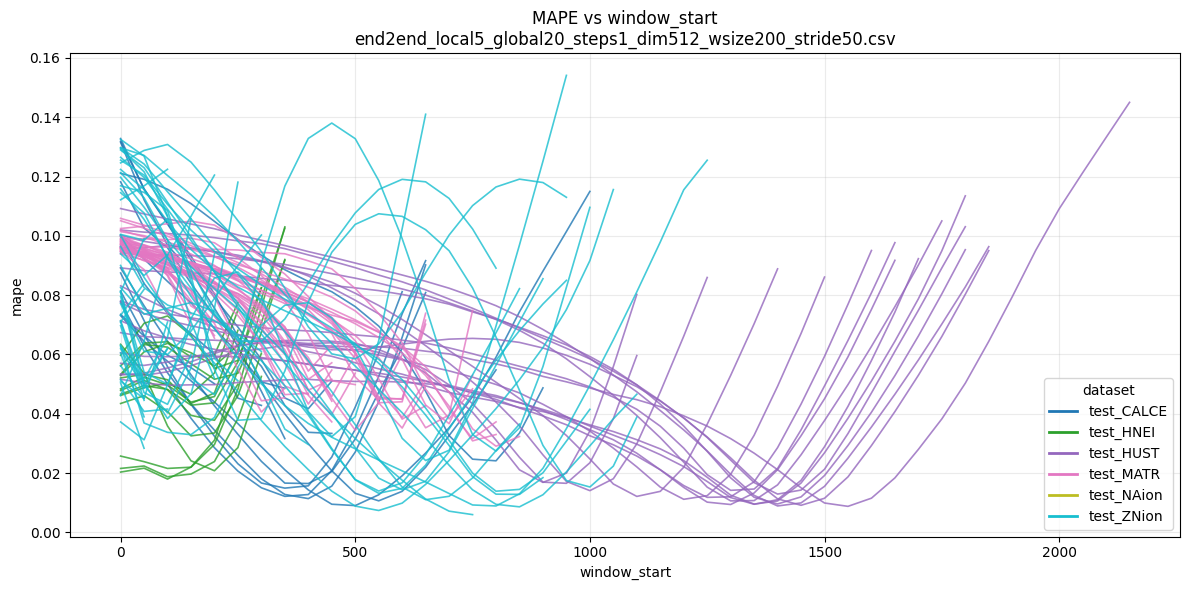

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


def plot_metrics_from_csv(csv_path, figsize=(12, 6), alpha=0.8, linewidth=1.2):
    """给定单个 CSV 路径，绘制 4 张折线图（mse/mae/rmse/mape）。

    规则：
    - x 轴: window_start
    - y 轴: 指标值（mse/mae/rmse/mape）
    - 每个 battery_name 一条线
    - 同一 dataset 使用同一种颜色
    - raw 指标不参与绘图
    """
    RESULT_DIR = Path('/home/syx/workspace/HyperBat/results/diffusion_results')
    csv_path = RESULT_DIR / csv_path
    if not csv_path.exists():
        raise FileNotFoundError(f'CSV 文件不存在: {csv_path}')

    df = pd.read_csv(csv_path)

    required_cols = {'dataset', 'battery_name', 'window_start', 'mse', 'mae', 'rmse', 'mape'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'CSV 缺少必要列: {sorted(missing_cols)}')

    metrics = ['mse', 'mae', 'rmse', 'mape']
    datasets = sorted(df['dataset'].dropna().unique())

    # 为每个 dataset 分配固定颜色
    cmap = plt.get_cmap('tab10', max(len(datasets), 1))
    color_map = {ds: cmap(i) for i, ds in enumerate(datasets)}

    # 按 dataset + battery_name 分组，保证每条线对应一个 battery
    grouped = []
    for (dataset, battery_name), g in df.groupby(['dataset', 'battery_name'], dropna=False):
        g_sorted = g.sort_values('window_start')
        grouped.append((dataset, battery_name, g_sorted))

    for metric in metrics:
        fig, ax = plt.subplots(figsize=figsize)

        for dataset, battery_name, g in grouped:
            ax.plot(
                g['window_start'],
                g[metric],
                color=color_map.get(dataset, 'gray'),
                alpha=alpha,
                linewidth=linewidth,
            )

        ax.set_title(f'{metric.upper()} vs window_start\n{csv_path.name}', fontsize=12)
        ax.set_xlabel('window_start')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

        # 图例只展示 dataset 颜色映射，避免 battery 太多导致图例过长
        legend_handles = [
            Line2D([0], [0], color=color_map[ds], lw=2, label=str(ds))
            for ds in datasets
        ]
        if legend_handles:
            ax.legend(handles=legend_handles, title='dataset', loc='best')

        plt.tight_layout()
        plt.show()

    return df


# 示例：替换为你想看的任意一个 csv 文件
_ = plot_metrics_from_csv('end2end_local5_global20_steps1_dim512_wsize200_stride50.csv')